In [7]:
import imgaug as ia
from imgaug import augmenters as iaa
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
os.chdir(r"D:\proj-python\Images_Vision")

In [20]:
images=[]
image_path=glob.glob(r"D:\proj-python\Images_Vision\dog_*.jpg")
for img in image_path:
    n=cv2.imread(img)
    images.append(n)
augmenters = iaa.Sequential([
    iaa.Fliplr(0.5),#horizontal flip.
   # iaa.Flipud(0.2),#vertical flip.
    iaa.Affine(translate_percent={"x":(-0.2,0.2),"y":(-0.2,0.2)}),#translate image.
    iaa.Affine(rotate=(-20,20), scale=(0.8,1.2)),#rotate and scale.
    iaa.Multiply((0.8,1.2)),#make image brighter/darker.
    iaa.GaussianBlur(sigma=(0,1.0)),#add blur.
    iaa.LinearContrast((0.2,1.2)),#increase or decrease contrast.
    iaa.Sometimes(0.5,iaa.AdditiveGaussianNoise(loc=0,scale=(0.0,0.05*255),per_channel=0.5)),#
])
augmeted_images=augmenters(images=images)

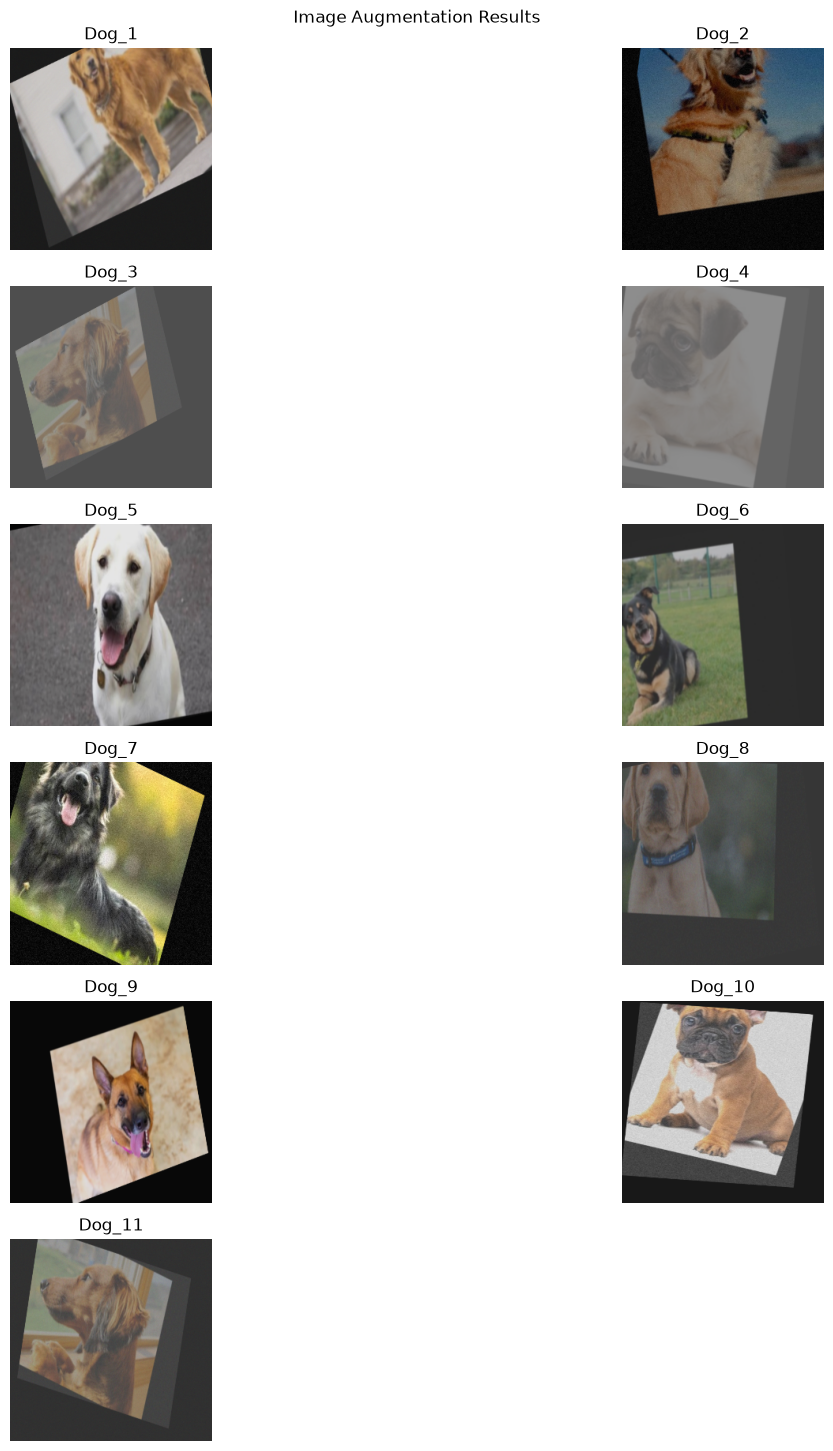

In [21]:
plt.figure(figsize=(15,15))
plt.suptitle("Image Augmentation Results")

for i,img in enumerate(augmeted_images):
    # cv2.imshow(f"Dog_{i}",img)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img=cv2.resize(img,(256,256))
    plt.subplot(len(augmeted_images)//2+1,2,i+1)
    # plt.subplot(6,2,i+1)
    plt.imshow(img)
    plt.tight_layout()
    plt.title(f"Dog_{i+1}")
    plt.axis("off")

plt.show()